# 🏈 QB Scouting Report Analyzer
Extracts and categorizes positive/negative quarterback traits from the `scouting_report` column in your CSV.

**Workflow:** Run all cells top to bottom. Results are saved to CSV and visualized inline.

## 1. Install & Import Dependencies

In [10]:
import re, warnings
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from transformers import pipeline

warnings.filterwarnings('ignore')
print("✅ Imports complete")

✅ Imports complete


In [11]:
pkgs = ["textblob", "pandas", "matplotlib", "seaborn", "tqdm"]
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ Dependencies ready")

✅ Dependencies ready


In [12]:
from textblob import TextBlob
print("✅ TextBlob ready")

✅ TextBlob ready


## 2. Configuration

In [13]:
# ── PATH TO YOUR CSV ──────────────────────────────────────────────
CSV_PATH = "cleaned_recruits_data.csv"   # update if needed
NAME_COL = "name"                        # column with player name
REPORT_COL = "scouting_report"           # column with report text

# ── QB TRAIT CATEGORIES ───────────────────────────────────────────
# Each category has keywords used to detect relevant sentences.
# Extend freely.
TRAIT_CATEGORIES = {
    "Arm Strength": [
        "arm strength", "velocity", "zip", "rocket", "cannon", "deep ball",
        "throws hard", "weak arm", "arm talent", "arm power", "touch",
        "loft", "trajectory", "rifle", "drive the ball"
    ],
    "Accuracy": [
        "accuracy", "accurate", "precision", "on-target", "off-target",
        "completion", "inaccurate", "placement", "inconsistent throws",
        "footwork", "mechanics", "throwing motion", "release", "high throws",
        "low throws", "sail", "ball speed"
    ],
    "Decision Making": [
        "decision", "reads", "pre-snap", "post-snap", "progression",
        "turnover", "interception", "fumble", "protect the ball",
        "quick trigger", "locks on", "stares down", "check down",
        "hot route", "audible", "coverage", "identifies"
    ],
    "Mobility & Athleticism": [
        "mobility", "mobile", "athletic", "scramble", "escapability",
        "speed", "dual-threat", "run threat", "elusive", "run",
        "extension plays", "chunk runs", "athlete"
    ],
    "Pocket Presence": [
        "pocket", "pressure", "step up", "navigate", "uncomfortable",
        "collapses", "happy feet", "statue", "anchors", "buys time",
        "off-platform", "unconventional", "sack"
    ],
    "Football IQ": [
        "football IQ", "smart", "intelligent", "understand", "scheme",
        "recognition", "anticipation", "anticipates", "diagnose",
        "protection", "blitz", "line calls", "adjustments",
        "reads defenses", "vision"
    ],
    "Leadership & Intangibles": [
        "leader", "leadership", "composure", "poise", "competitive",
        "work ethic", "film study", "coachable", "character",
        "locker room", "clutch", "demeanor", "mature", "mental",
        "confidence", "magnetism"
    ],
    "Size & Physical": [
        "size", "height", "weight", "frame", "build", "stature",
        "durability", "injury", "prototype", "undersized", "bulk",
        "slender", "narrow", "mass", "body"
    ],
    "NFL / Draft Projection": [
        "nfl", "draft", "projects", "round", "professional", "next level",
        "franchise", "starter", "upside", "ceiling", "floor"
    ],
}

print(f"📋 Tracking {len(TRAIT_CATEGORIES)} trait categories")

📋 Tracking 9 trait categories


## 3. Load Data

In [14]:
df_raw = pd.read_csv('../Data/cleaned_recruits_data.csv')
df_raw = df_raw.dropna(subset=[REPORT_COL])

print(f"✅ Loaded {len(df_raw)} QBs from '{CSV_PATH}'")
print(f"   Columns available: {df_raw.columns.tolist()}")
df_raw[[NAME_COL, REPORT_COL]].head(3)

✅ Loaded 152 QBs from 'cleaned_recruits_data.csv'
   Columns available: ['name', 'url', 'rank', 'height', 'weight', 'composite_rating', 'school_info', 'city', 'state', 'scouting_report', 'draft_projection', 'reminds_of', 'evaluated_date', 'analyst', 'athletic_background', 'committed_school', 'numerical_rating', 'Is_FBS', 'Is_SEC', 'Is_Big_Ten', 'Is_Big_XII', 'Is_ACC', 'pos_DUAL', 'pos_PRO', 'pos_QB', 'star_2', 'star_3', 'star_4', 'star_5', 'Is_Top_Five_Ranked', 'Is_From_East', 'Is_From_West', 'weight_to_height_ratio', 'bmi']


,name,scouting_report
0,Spencer Rattler,Slightly built prospect with narrow shoulders....
1,Jayden Daniels,Possesses a naturally slender build and frame....
2,Bo Nix,Big enough quarterback with some stockiness th...


## 4. Sentence Segmentation & Trait Detection

In [15]:
def split_sentences(text: str) -> list:
    raw = re.split(r'(?<=[.!?])\s+', text.replace("\n", " "))
    return [s.strip() for s in raw if len(s.strip()) > 20]

def detect_categories(sentence: str) -> list:
    sl = sentence.lower()
    return [cat for cat, kws in TRAIT_CATEGORIES.items()
            if any(kw.lower() in sl for kw in kws)]

records = []
for _, row in df_raw.iterrows():
    player = row[NAME_COL]
    for sent in split_sentences(str(row[REPORT_COL])):
        cats = detect_categories(sent)
        if cats:
            records.append({"player": player, "sentence": sent, "categories": cats})

df_sents = pd.DataFrame(records)
print(f"✅ {len(df_sents)} trait-relevant sentences across {df_sents['player'].nunique()} QBs")
df_sents.head(4)

texts = df_sents["sentence"].tolist()
print(f"✅ {len(df_sents)} trait-relevant sentences | {len(texts)} ready to score")

✅ 1297 trait-relevant sentences across 152 QBs
✅ 1297 trait-relevant sentences | 1297 ready to score


## 5. Sentiment Scoring

In [16]:
# TextBlob scores inline — no separate model loading needed
print("✅ Sentiment scoring uses TextBlob (offline, no download required)")

✅ Sentiment scoring uses TextBlob (offline, no download required)


In [17]:
from textblob import TextBlob
from tqdm import tqdm

scores = [TextBlob(t).sentiment.polarity for t in tqdm(texts, desc="Scoring")]

df_sents["score"] = scores
df_sents["sentiment"] = df_sents["score"].apply(lambda x: "POSITIVE" if x >= 0 else "NEGATIVE")

df_exp = df_sents.explode("categories").rename(columns={"categories": "category"})

print(f"✅ Done  |  POSITIVE: {(df_sents.sentiment=="POSITIVE").sum()}  |  NEGATIVE: {(df_sents.sentiment=="NEGATIVE").sum()}")
df_sents[["player","sentence","sentiment","score"]].head(5)

Scoring: 100%|██████████| 1297/1297 [00:00<00:00, 5135.21it/s]

✅ Done  |  POSITIVE: 1132  |  NEGATIVE: 165


,player,sentence,sentiment,score
0,Spencer Rattler,Slightly built prospect with narrow shoulders.,NEGATIVE,-0.183333
1,Spencer Rattler,Limited physical upside.,NEGATIVE,-0.035714
2,Spencer Rattler,Natural passer with a quick release.,POSITIVE,0.216667
3,Spencer Rattler,Does not need to load up to generate velocity.,POSITIVE,0.000000
4,Spencer Rattler,Throws with more zip than power.,POSITIVE,0.500000


## 6. Per-Player Trait Summary Table

In [18]:
summary = (
    df_exp.groupby(["player", "category", "sentiment"])
    .agg(count=("sentence", "count"), avg_score=("score", "mean"))
    .reset_index()
)

pivot = summary.pivot_table(
    index=["player", "category"], columns="sentiment",
    values="count", fill_value=0
).reset_index()

cat_scores = (
    df_exp.groupby(["player", "category"])["score"]
    .mean().reset_index().rename(columns={"score": "mean_score"})
)
pivot = pivot.merge(cat_scores, on=["player", "category"])
pivot["mean_score"] = pivot["mean_score"].round(3)
for col in ["POSITIVE", "NEGATIVE"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot.sort_values(["player", "mean_score"], ascending=[True, False])
print("📊 Trait Summary — scroll right to see all columns")
pivot.style.background_gradient(subset=["mean_score"], cmap="RdYlGn", vmin=-1, vmax=1)

📊 Trait Summary — scroll right to see all columns


,player,category,NEGATIVE,POSITIVE,mean_score
4,AJ Duffy,Pocket Presence,0.000000,1.000000,0.197000
1,AJ Duffy,Arm Strength,0.000000,1.000000,0.100000
2,AJ Duffy,Decision Making,0.000000,2.000000,0.070000
0,AJ Duffy,Accuracy,0.000000,1.000000,0.045000
3,AJ Duffy,Mobility & Athleticism,0.000000,1.000000,0.000000
6,AJ Swann,Arm Strength,1.000000,1.000000,0.190000
7,AJ Swann,Decision Making,0.000000,1.000000,0.183000
8,AJ Swann,NFL / Draft Projection,0.000000,1.000000,0.183000
5,AJ Swann,Accuracy,1.000000,0.000000,-0.075000
9,AJ Swann,Pocket Presence,2.000000,0.000000,-0.115000


## 7. Top Positive & Negative Trait Sentences per Player

In [19]:
# ── Configure which players to print ─────────────────────────────
# Set to None to print ALL players, or pass a list e.g.:
#   PLAYERS_TO_SHOW = ["Spencer Rattler", "Jayden Daniels"]
PLAYERS_TO_SHOW = None   # ← change here
TOP_N = 5                # sentences per sentiment per player
# ─────────────────────────────────────────────────────────────────

players = df_sents["player"].unique() if PLAYERS_TO_SHOW is None else PLAYERS_TO_SHOW

for player in players:
    sub = df_sents[df_sents["player"] == player]
    pos = sub[sub["sentiment"] == "POSITIVE"].nlargest(TOP_N, "score")
    neg = sub[sub["sentiment"] == "NEGATIVE"].nsmallest(TOP_N, "score")

    print(f"{'='*72}")
    print(f"  🏈  {player}")
    print(f"{'='*72}")

    print("  ✅ STRENGTHS")
    for _, r in pos.iterrows():
        cats = ", ".join(r["categories"]) if isinstance(r["categories"], list) else r["categories"]
        print(f"    [{r['score']:+.3f}] [{cats}]")
        print(f"    {r['sentence']}")
        print()

    print("  ❌ CONCERNS")
    for _, r in neg.iterrows():
        cats = ", ".join(r["categories"]) if isinstance(r["categories"], list) else r["categories"]
        print(f"    [{r['score']:+.3f}] [{cats}]")
        print(f"    {r['sentence']}")
        print()
    print()

  🏈  Spencer Rattler
  ✅ STRENGTHS
    [+0.500] [Arm Strength]
    Throws with more zip than power.

    [+0.400] [Accuracy]
    Accurate in ball placement.

    [+0.217] [Accuracy]
    Natural passer with a quick release.

    [+0.100] [Leadership & Intangibles]
    Has some natural confidence and magnetism as a leader.

    [+0.000] [Arm Strength]
    Does not need to load up to generate velocity.

  ❌ CONCERNS
    [-0.183] [Size & Physical]
    Slightly built prospect with narrow shoulders.

    [-0.083] [Pocket Presence]
    Disassociates his upper and lower half to make off-platform, unconventional throws with ease.

    [-0.077] [Decision Making]
    Can play too loose at times which ticks his interception numbers up some.

    [-0.036] [NFL / Draft Projection]
    Limited physical upside.


  🏈  Jayden Daniels
  ✅ STRENGTHS
    [+0.600] [Arm Strength, Accuracy, Mobility & Athleticism]
    Does a nice job of changing ball speed and putting touch on throws.

    [+0.500] [Mobility

## 8. Visualizations

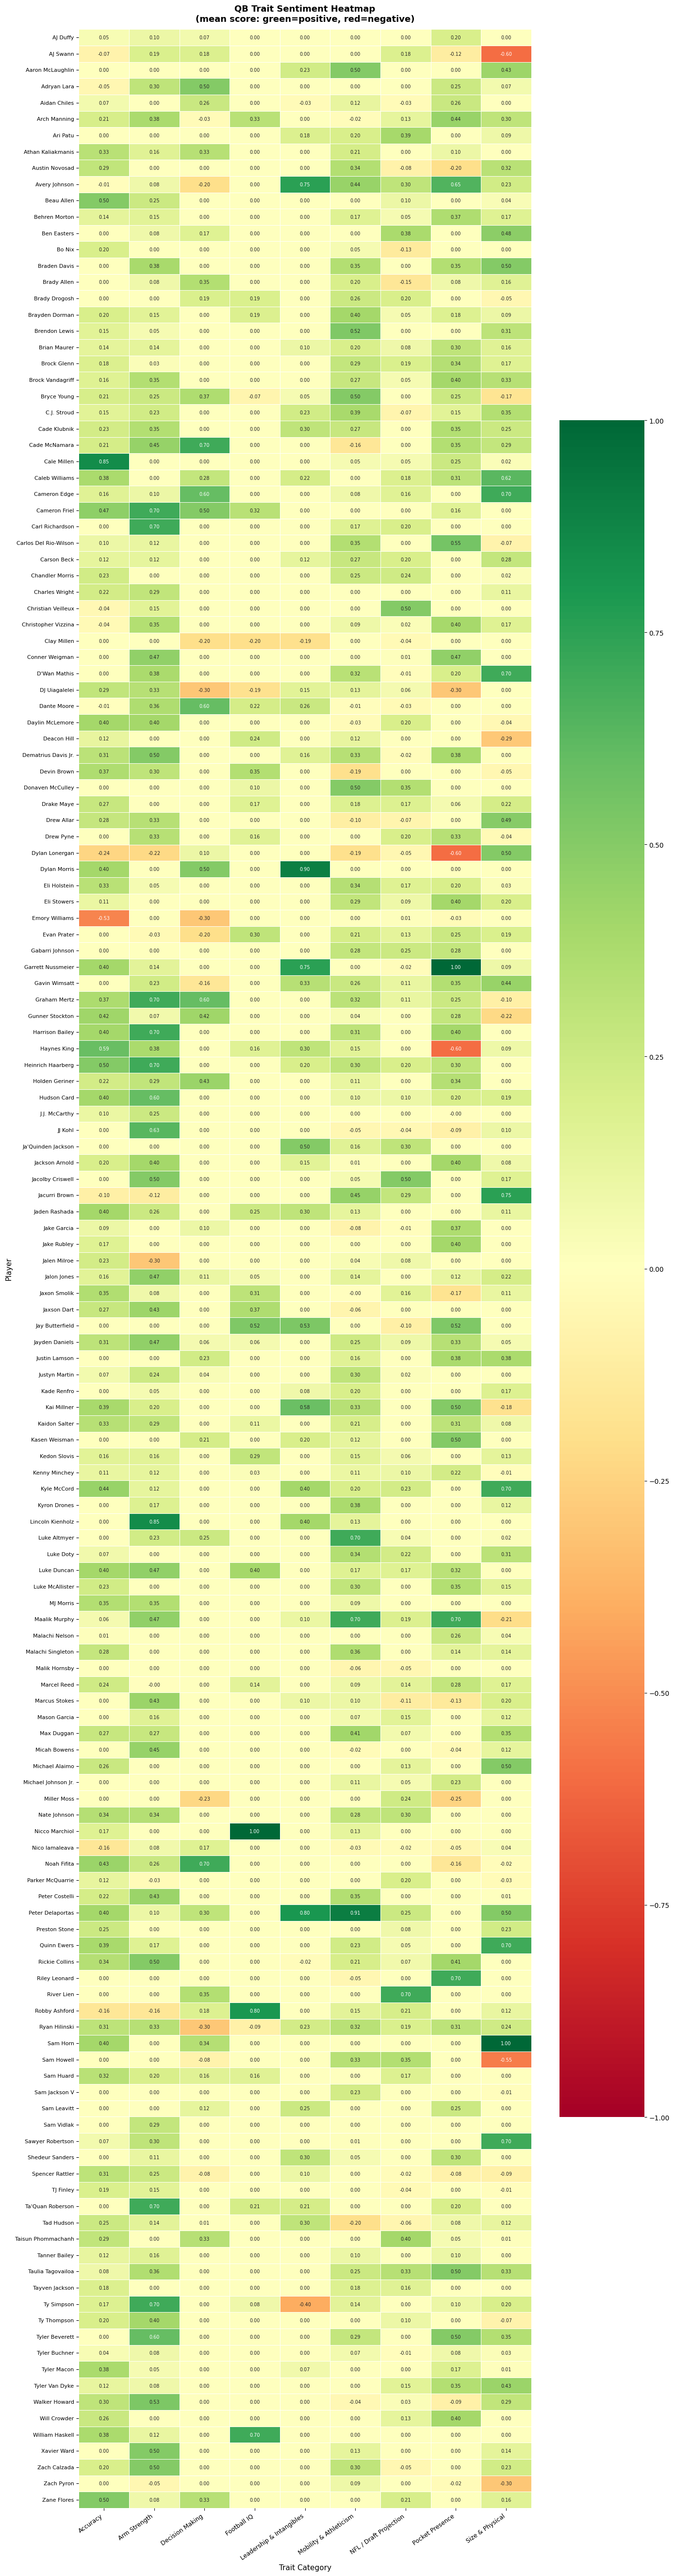

In [20]:
# ── Chart 1: Comparison heatmap — all QBs × all categories ──
heatmap_data = (
    df_exp.groupby(["player", "category"])["score"]
    .mean().unstack(fill_value=0)
)

fig_h = max(8, len(heatmap_data) * 0.35)
fig, ax = plt.subplots(figsize=(14, fig_h))
sns.heatmap(
    heatmap_data, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-1, vmax=1,
    linewidths=0.4, ax=ax, annot_kws={"size": 7}
)
ax.set_title("QB Trait Sentiment Heatmap\n(mean score: green=positive, red=negative)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Trait Category", fontsize=11)
ax.set_ylabel("Player", fontsize=11)
plt.xticks(rotation=35, ha="right", fontsize=9)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig("qb_heatmap_all.png", dpi=150, bbox_inches="tight")
plt.show()

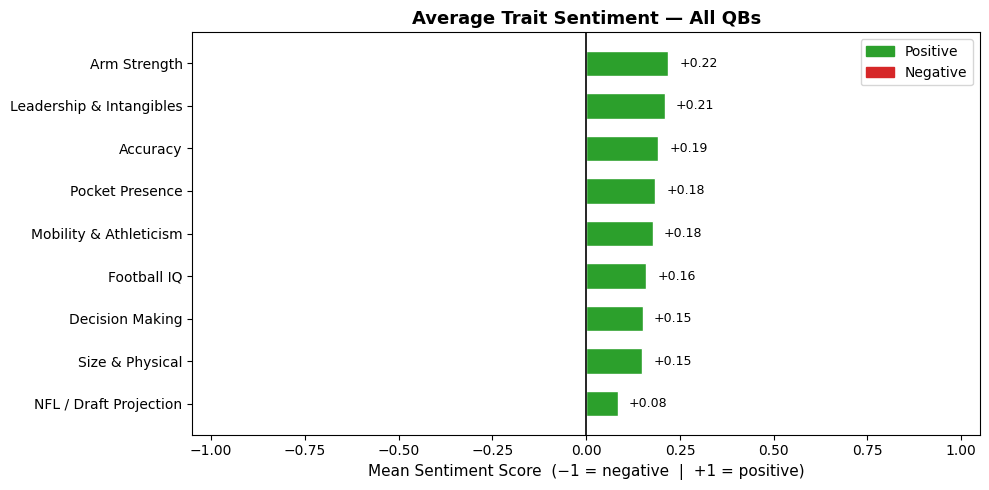

In [21]:
# ── Chart 2: Fleet-wide average sentiment per category ──
fleet_avg = df_exp.groupby("category")["score"].mean().sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in fleet_avg.values]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(fleet_avg.index, fleet_avg.values, color=colors, edgecolor="white", height=0.6)
ax.axvline(0, color="black", linewidth=1.2)
ax.set_xlabel("Mean Sentiment Score  (−1 = negative  |  +1 = positive)", fontsize=11)
ax.set_title("Average Trait Sentiment — All QBs", fontsize=13, fontweight="bold")
ax.set_xlim(-1.05, 1.05)
for bar, val in zip(bars, fleet_avg.values):
    x = val + (0.03 if val >= 0 else -0.03)
    ax.text(x, bar.get_y() + bar.get_height()/2, f"{val:+.2f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=9)
pos_p = mpatches.Patch(color="#2ca02c", label="Positive")
neg_p = mpatches.Patch(color="#d62728", label="Negative")
ax.legend(handles=[pos_p, neg_p])
plt.tight_layout()
plt.savefig("qb_fleet_avg.png", dpi=150)
plt.show()

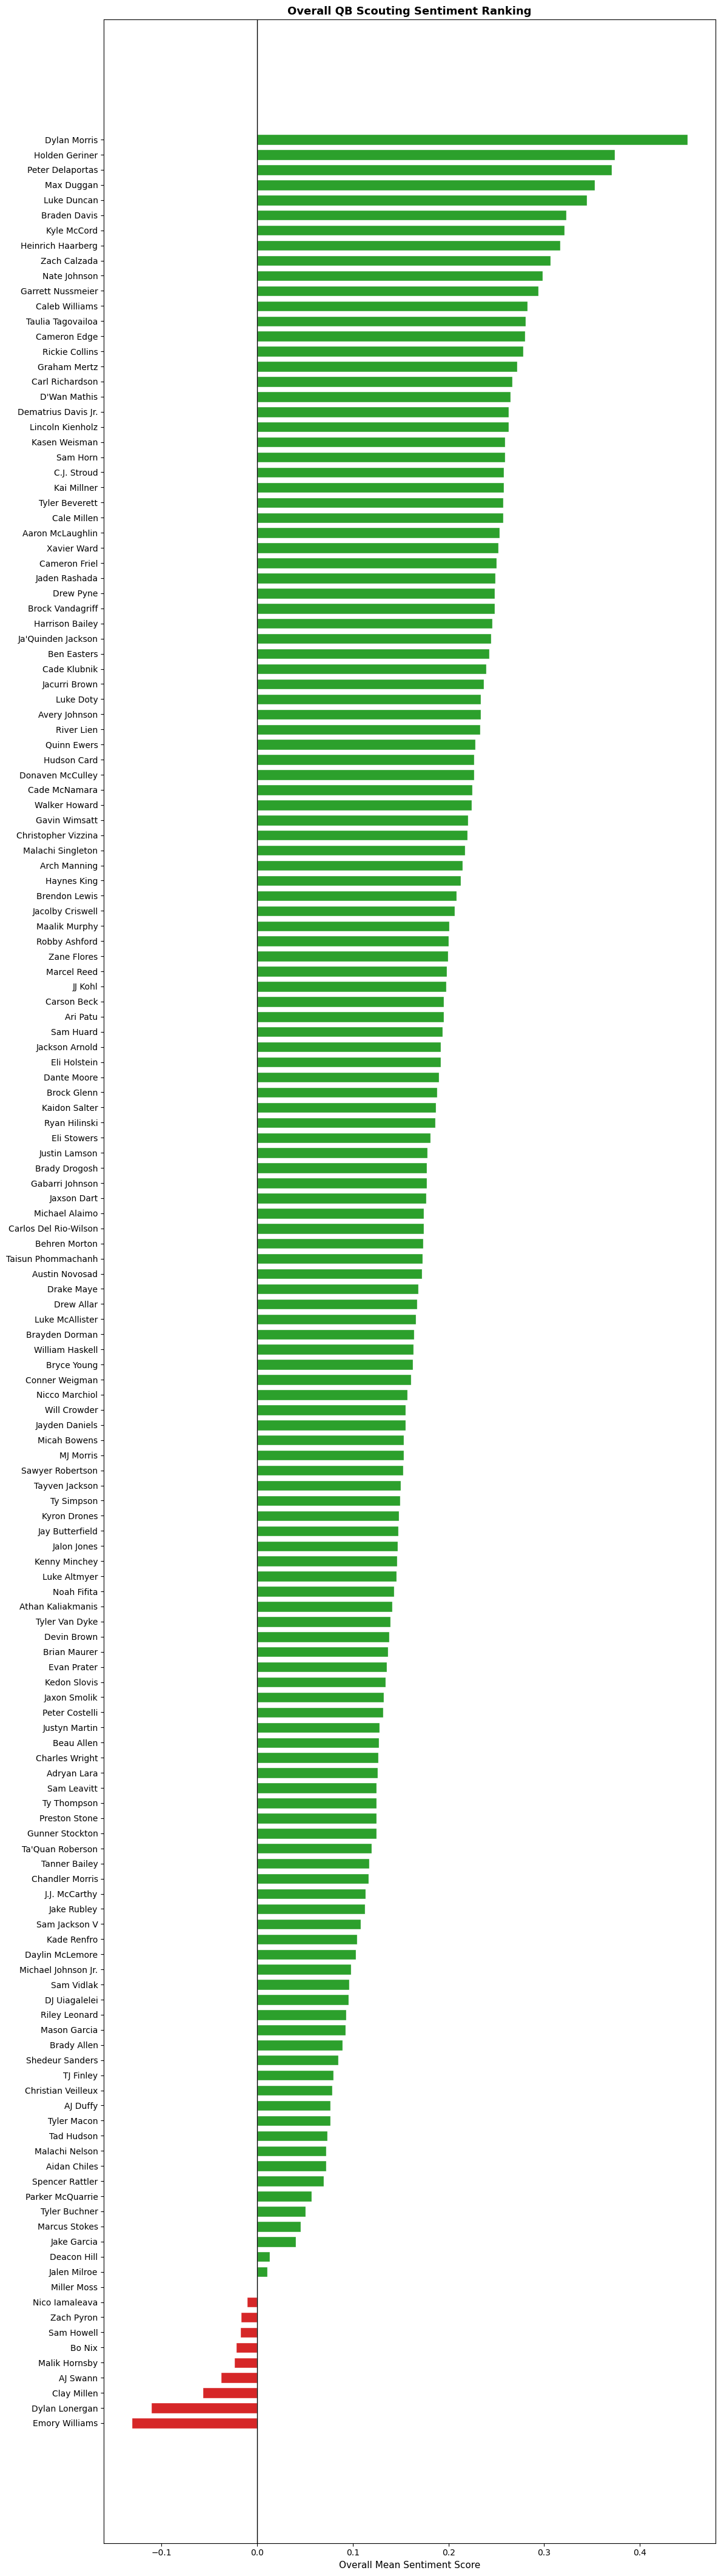

In [22]:
# ── Chart 3: Per-player overall score (bar chart) ──
overall = df_sents.groupby("player")["score"].mean().sort_values(ascending=False)
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in overall.values]

fig, ax = plt.subplots(figsize=(12, max(5, len(overall)*0.28)))
ax.barh(overall.index[::-1], overall.values[::-1], color=colors[::-1], edgecolor="white", height=0.7)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Overall Mean Sentiment Score", fontsize=11)
ax.set_title("Overall QB Scouting Sentiment Ranking", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("qb_overall_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export Results

In [23]:
# ── Wide-format CSV: one row per player, one column per trait category ──
wide = (
    df_exp.groupby(["player", "category"])["score"]
    .mean()
    .unstack(fill_value=None)
    .reset_index()
)
wide.columns.name = None
wide = wide.round(4)

# Merge metadata columns from original CSV
meta_cols = [c for c in df_raw.columns if c not in [REPORT_COL, NAME_COL]]
if meta_cols:
    wide = df_raw[[NAME_COL] + meta_cols].merge(wide, left_on=NAME_COL, right_on="player", how="right")
    wide = wide.drop(columns=["player"]).rename(columns={NAME_COL: "player"})

cols = ["player"] + [c for c in wide.columns if c != "player"]
wide = wide[cols]

wide.to_csv("qb_trait_scores.csv", index=False)
print(f"✅ Exported qb_trait_scores.csv — {len(wide)} players × {len(wide.columns)} columns")
wide.head()

✅ Exported qb_trait_scores.csv — 152 players × 42 columns


,player,url,rank,height,weight,composite_rating,school_info,city,state,draft_projection,...,bmi,Accuracy,Arm Strength,Decision Making,Football IQ,Leadership & Intangibles,Mobility & Athleticism,NFL / Draft Projection,Pocket Presence,Size & Physical
0,AJ Duffy,https://247sports.com/player/aj-duffy-46079777/,13,74.0,223,91,"IMG Academy (Bradenton, FL)",Bradenton,FL,4-7 Round - Day 3,...,28.628378,0.0455,0.1000,0.0702,NaN,NaN,0.0000,NaN,0.1972,NaN
1,AJ Swann,https://247sports.com/player/aj-swann-46083200/,22,74.5,200,89,"Cherokee (Canton, GA)",Canton,GA,Power 4 Starter,...,25.332192,-0.0750,0.1903,0.1833,NaN,NaN,NaN,0.1833,-0.1153,-0.6000
2,Aaron McLaughlin,https://247sports.com/player/aaron-mclaughlin-...,65,77.0,219,86,"Denmark (Alpharetta, GA)",Alpharetta,GA,Power 4 Starter,...,25.966773,0.0000,0.0000,NaN,NaN,0.2333,0.5000,0.0000,0.0000,0.4278
3,Adryan Lara,https://247sports.com/player/adryan-lara-46082...,65,74.0,215,85,"Desert Edge (Goodyear, AZ)",Goodyear,AZ,Power 4 Starter,...,27.601351,-0.0500,0.3000,0.5000,NaN,NaN,NaN,0.0000,0.2500,0.0667
4,Aidan Chiles,https://247sports.com/player/aidan-chiles-4611...,7,76.0,195,96,"Downey (Downey, CA)",Downey,CA,4-7 Round - Day 3,...,23.733553,0.0694,NaN,0.2600,NaN,-0.0286,0.1238,-0.0286,0.2600,NaN
